# SHFLI Burst Mode — Ring-Down Measurement & Q-Factor Extraction

Measures the **mechanical/resonator ring-down** of a resonator driven by the SHFLI.
The drive tone is switched off via a software trigger; the demodulator captures the
free decay of the oscillator, from which the energy decay time τ and quality factor Q
are extracted by exponential fitting.

**Instrument:** Zurich Instruments SHFLI (`dev12470`)  
**Method:** DAQ module in burst-trigger mode — 200 k samples at 50 MSa/s (4 ms window)  
**Output:** τ (decay time), Q = π · f₀ · τ

## 1. Setup

Import required libraries and connect to the SHFLI via a zhinst.toolkit `Session`.
Set `server_host` to `'localhost'` for a locally connected device or the instrument's
IP address for remote access.

In [1]:
# Copyright 2023 Zurich Instruments AG

import time
from timeit import default_timer as timer
import numpy as np
from zhinst.toolkit import Session, CommandTable
import matplotlib.pyplot as plt

In [2]:
device_id = "dev12470" # Device serial number available on its rear panel.
server_host ='localhost'
#server_host="10.42.193.0"
## connect to data server
session = Session(server_host, allow_version_mismatch=True  )
## connect to device
shfli = session.connect_device(device_id)
print(shfli)

BaseInstrument(SHFLI(AWG,FF,MF,MOD,PID),dev12470)


## 2. Acquisition

### 2a. Acquisition Function

`ringdown_acquire()` arms the DAQ module, fires a software trigger (which marks t = 0
for the burst), and immediately turns off the output generator. It then waits for the
DAQ to finish collecting the burst and plots the raw X / Y demodulator quadratures vs. time.

> **Trigger sequence:** arm DAQ → fire swtrigger → disable sigout → wait → read → re-enable sigout

In [3]:
def ringdown_acquire(daq_module, sample_nodes, clockbase):
    """Arm DAQ, turn off generator, fire software trigger immediately."""

    # 1. Arm DAQ
    daq_module.execute()

    # 2. Turn off drive generator and fire trigger as fast as possible
    
    #shfli.sigouts[0].on(0)  # disable excitation generator
    shfli.system.swtriggers[0].single(1)        # fire software trigger
    time.sleep(1e-3)  # short delay to ensure trigger is registered before turning off generator
    shfli.sigouts[0].on(0) 
    # 3. Wait for DAQ to finish       # fire software trigger

    # 3. Wait for DAQ to finish
    start = timer()
    while not daq_module.finished():
        time.sleep(1e-3)
        if timer() - start > 10:
            print("Timeout — no trigger received")
            break

    daq_data = daq_module.read(raw=False, clk_rate=clockbase)
    daq_module.finish()

    # 4. Re-enable generator for next measurement
    shfli.sigouts[0].on(1) 

    # 5. Extract and plot
    fig, ax = plt.subplots(figsize=(10, 4))
    for node in sample_nodes:
        if node in daq_data:
            for burst in daq_data[node]:
                t_us = burst.time * 1e6
                ax.plot(t_us, burst.value[0, :], label=str(node).split("/")[-1])
    ax.set_xlabel("Time after trigger (µs)")
    ax.set_ylabel("Signal (V)")
    ax.set_title(f"Ring-Down — SHFLI {device_id.upper()}")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return daq_data

### 2b. Measurement Parameters

| Parameter | Value | Notes |
|---|---|---|
| `demod_index` | 0 | Demodulator 1 (0-based) |
| `num_bursts` | 200 000 samples | Samples per burst |
| `data_rate` | 50 MSa/s | → 4 ms capture window |
| `demod_tc` | 30 ns | Short TC to follow fast transients |
| `trigger_delay` | 500 µs | DAQ pre-trigger delay |
| `trigger_count` | 1 | Single burst per acquisition |

In [4]:
demod_index  = 0         # demodulator 1 (0-based)
num_bursts   = 200e3        # samples per burst
data_rate    = 50e6       # 50 MSa/sec
demod_tc     = 30e-9
soft_trigger = 1024       # software trigger source enum
trigger_count = 1
trigger_delay = 500e-6

print(f"Capture window: {num_bursts/data_rate*1e6:.1f} µs at {data_rate/1e6:.0f} MSa/sec")

triggernode_path = f"/dev12470/demods/{demod_index}/sample.TrigIndex"
sample_nodes = [
    shfli.demods[demod_index].sample.x,
    shfli.demods[demod_index].sample.y,
]

Capture window: 4000.0 µs at 50 MSa/sec


### 2c. Demodulator & DAQ Configuration

Configures the demodulator (time constant, trigger source, burst length, sample rate)
and the DAQ module in **burst_trigger** mode. The DAQ subscribes to X and Y sample
nodes and waits for the software trigger index (`1024`) to start capture.

In [5]:
with shfli.set_transaction():
    shfli.demods[demod_index].timeconstant(demod_tc)
    shfli.demods[demod_index].trigger.source(soft_trigger)
    shfli.demods[demod_index].trigger.triggeracq(1)
    shfli.demods[demod_index].burstlen(num_bursts)
    shfli.demods[demod_index].rate(data_rate)
    shfli.demods[demod_index].bypass(0)   # start with bypass OFF
    shfli.demods[demod_index].enable(1)

daq_module = session.modules.daq
daq_module.device(device_id)
daq_module.type("burst_trigger")
daq_module.delay(trigger_delay)
daq_module.grid.mode("exact")
daq_module.count(trigger_count)
daq_module.grid.cols(num_bursts)
daq_module.triggernode(triggernode_path)

for node in sample_nodes:
    daq_module.subscribe(node)

clockbase = shfli.clockbase()
print("DAQ configured.")

DAQ configured.


### 2d. Diagnostic Check

Verify that the output and generator are in the expected state before acquisition.
Both should be **ON** (1) before calling `ringdown_acquire()` — the function turns
the output off after trigger to start the ring-down.

In [6]:
# ── Diagnostic: check demodulator sees signal ────────────────────────────
# Run with output ON before acquiring ring-down
#r_now = shfli.demods[demod_index].sample.r()
# print(f"Demod {demod_index} R = {r_now:.6f} V  (should be > 0 if signal is on)")
print(f"Output on: {shfli.sigouts[0].on()}")
print(f"Generator 3 enabled: {shfli.sigouts[0].generators[3].enable()}")

Output on: 0
Generator 3 enabled: 0


### 2e. Run Acquisition

Calls `ringdown_acquire()`. The function arms the DAQ, fires the trigger, captures
the burst, re-enables the output, and plots X / Y vs. time.

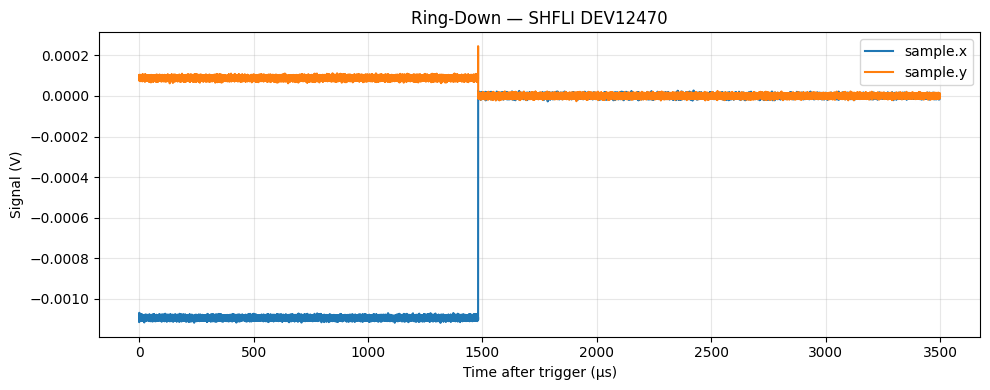

In [10]:
daq_data = ringdown_acquire(daq_module, sample_nodes, clockbase)

## 3. Save Data

Extracts time, X, Y, and amplitude R = √(X² + Y²) from the first burst and saves
them to a timestamped `.npz` file alongside metadata (`data_rate`, `num_bursts`).

In [72]:
import os
from datetime import datetime

# ── Output folder and filename ───────────────────────────────────────────
save_dir  = os.path.dirname(os.path.abspath("__file__"))
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = os.path.join(save_dir, f"ringdown_{timestamp}")

# ── Extract time and signal arrays from daq_data ─────────────────────────
all_time, all_x, all_y = [], [], []

x_node = shfli.demods[demod_index].sample.x
y_node = shfli.demods[demod_index].sample.y

if x_node in daq_data and y_node in daq_data:
    for burst_x, burst_y in zip(daq_data[x_node], daq_data[y_node]):
        t   = burst_x.time                  # time relative to trigger (s)
        x   = burst_x.value[0, :]           # in-phase
        y   = burst_y.value[0, :]           # quadrature
        all_time.append(t)
        all_x.append(x)
        all_y.append(y)

    t_arr = all_time[0]                      # time axis of first burst (s)
    x_arr = all_x[0]
    y_arr = all_y[0]
    r_arr = np.abs(x_arr + 1j * y_arr)      # amplitude

    # ── Save as .npz ─────────────────────────────────────────────────────
    np.savez(
        save_path,
        time_s   = t_arr,
        time_us  = t_arr * 1e6,
        x        = x_arr,
        y        = y_arr,
        r        = r_arr,
        data_rate= data_rate,
        num_bursts = num_bursts,
    )
    print(f"Saved: {save_path}.npz")
    print(f"  Time axis : {t_arr[0]*1e6:.3f} to {t_arr[-1]*1e6:.3f} µs  ({len(t_arr)} points)")
    print(f"  R range   : {r_arr.min():.4f} to {r_arr.max():.4f} V")
else:
    print("No data found in daq_data — run acquisition first")

Saved: /Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Python/Toolkit/SHFLI/ringdown_20260428_172222.npz
  Time axis : 0.000 to 4611657560433189.000 µs  (200000 points)
  R range   : nan to nan V


### 3a. Reload & Plot Saved Data

Load a previously saved `.npz` file and plot R, X, Y vs. time. Change `load_path`
to replay any earlier measurement without re-running the hardware.

Keys: ['time_s', 'time_us', 'x', 'y', 'r', 'data_rate', 'num_bursts']


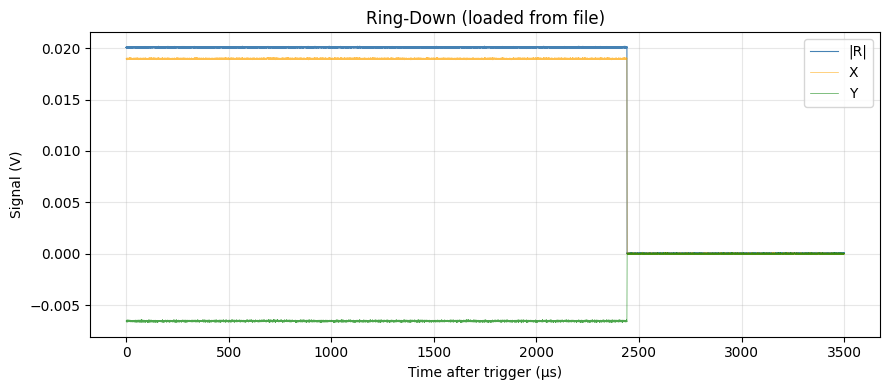

/Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Python/Toolkit/SHFLI/ringdown_20260428_172222.npz


In [73]:
# Load a previously saved file
# load_path = "ringdown_20260416_123456.npz"  # ← change to your filename
load_path = save_path + ".npz"

d = np.load(load_path)
print("Keys:", list(d.keys()))

t_us = d["time_us"]
r     = d["r"]
x     = d["x"]
y     = d["y"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_us, r, lw=0.8, color="steelblue", label="|R|")
ax.plot(t_us, x, lw=0.5, color="orange", alpha=0.7, label="X")
ax.plot(t_us, y, lw=0.5, color="green",  alpha=0.7, label="Y")
ax.set_xlabel("Time after trigger (µs)")
ax.set_ylabel("Signal (V)")
ax.set_yscale("linear")
ax.set_title(f"Ring-Down (loaded from file)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(load_path)

## 4. Q-Factor Extraction

Fits the ring-down amplitude to an exponential decay:

$$R(t) = A \cdot e^{-t/\tau} + C$$

The quality factor is then:

$$Q = \pi \cdot f_0 \cdot \tau$$

`fit_ringdown_lockin()` auto-detects the drive-off time t_off from the steepest
negative gradient, skips an initial transient fraction, and returns τ, Q, and their
uncertainties from the covariance matrix of the fit.

In [68]:
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

def fit_ringdown_lockin(t_s, amplitude, f0=3.75e9,
                        t_off=None, t_stop=None,
                        smooth_pts=51, skip_transient=0.05,
                        plot=True):
    """
    Fit exponential decay to lock-in ring-down (rotating frame).
    t_off is auto-detected from the steepest drop if not provided.
    t_s and t_off must be in seconds.
    """

    def exp_decay(t, A, tau, C):
        return A * np.exp(-t / tau) + C

    # ── Sanity check ─────────────────────────────────────────────────────────
    if np.all(np.isnan(amplitude)):
        print("ERROR: amplitude is all NaN — DAQ did not capture valid data.")
        print("       Check trigger timing and re-run the acquisition cell.")
        return None

    # ── Auto-detect t_off ────────────────────────────────────────────────────
    auto_detected = t_off is None
    if auto_detected:
        smoothed = uniform_filter1d(amplitude.astype(float), size=smooth_pts)
        grad     = np.gradient(smoothed, t_s)       # t_s must be an array, not the time module!
        t_off    = t_s[np.argmin(grad)]

    # ── Define fit window ────────────────────────────────────────────────────
    t1   = t_stop if t_stop is not None else t_s[-1]
    mask = (t_s >= t_off) & (t_s <= t1)

    t_win = t_s[mask] - t_s[mask][0]
    sig   = amplitude[mask]

    skip  = max(int(skip_transient * len(sig)), 1)
    t_fit = t_win[skip:]
    s_fit = sig[skip:]

    # ── Robust initial guesses ───────────────────────────────────────────────
    C0   = np.nanmedian(s_fit[int(0.8 * len(s_fit)):])
    A0   = max(np.nanmedian(s_fit[:max(int(0.1 * len(s_fit)), 5)]) - C0, 1e-12)
    idx  = np.argmin(np.abs(s_fit - (C0 + A0 / np.e)))
    tau0 = max(t_fit[idx], (t_fit[-1] - t_fit[0]) * 1e-3)

    try:
        popt, pcov = curve_fit(
            exp_decay, t_fit, s_fit,
            p0=[A0, tau0, C0],
            bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
            maxfev=10_000
        )
    except RuntimeError as e:
        print(f"Fit did not converge: {e}")
        return None

    A_fit, tau_fit, C_fit = popt
    tau_err = np.sqrt(pcov[1, 1])
    Q       = np.pi * f0 * tau_fit
    Q_err   = np.pi * f0 * tau_err

    print(f"t_off = {t_off * 1e6:.3f} µs  ({'auto-detected' if auto_detected else 'manual'})")
    print(f"τ     = {tau_fit * 1e6:.3f} ± {tau_err * 1e6:.3f} µs")
    print(f"Q     = {Q:.0f} ± {Q_err:.0f}")

    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

        ax1.plot(t_s * 1e6, amplitude, color='steelblue', lw=0.8)
        ax1.axvline(t_off * 1e6, color='gray', ls='--', lw=1, label='t_off')
        ax1.set_ylabel('Amplitude (V)')
        ax1.set_title(f'Full trace  —  f₀ = {f0/1e9:.4f} GHz')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        t_fine = np.linspace(t_fit[0], t_fit[-1], 1000)
        ax2.plot(t_win * 1e6, sig, color='steelblue', lw=0.8, alpha=0.6, label='Ring-down')
        ax2.plot((t_fine + t_win[skip]) * 1e6, exp_decay(t_fine, *popt), 'r', lw=2,
                 label=fr'Fit: $\tau$ = {tau_fit*1e6:.2f} µs,  Q = {Q:.0f}')
        ax2.axvspan(0, t_win[skip] * 1e6, color='gray', alpha=0.15, label='Skipped transient')
        ax2.set_xlabel('Time from drive-off (µs)')
        ax2.set_ylabel('Amplitude (V)')
        ax2.set_title('Ring-down fit')
        ax2.legend(); ax2.grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()

    return {'tau': tau_fit, 'tau_err': tau_err, 'Q': Q, 'Q_err': Q_err, 't_off': t_off}


# ── Load and fit ──────────────────────────────────────────────────────────────
# Note: use t_s (seconds), NOT the variable called 'time' which is Python's time module
t_s       = t_us      # seconds — from the load cell above
amplitude = r           # amplitude R = sqrt(X²+Y²)

result = fit_ringdown_lockin(t_s, amplitude, f0=3.75e9)


/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1311: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1311: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/var/folders/dy/n7hsxx852xq2bytn1n_nl9vm0000gp/T/ipykernel_53661/766616168.py:42: RuntimeWarning: All-NaN slice encountered
  C0   = np.nanmedian(s_fit[int

ValueError: array must not contain infs or NaNs

### 4a. Example Usage

Three common calling patterns for `fit_ringdown_lockin()`:
- **Fully automatic** — t_off auto-detected from the gradient
- **Manual t_off** — override if auto-detection picks the wrong edge
- **Increased transient skip** — useful when the switch-off has a slow tail

In [ ]:
amplitude = r
# Fully automatic
result = fit_ringdown_lockin(time, amplitude, f0=3.75e9)

# Manual t_off if auto-detection picks wrong spot
result = fit_ringdown_lockin(time, amplitude, f0=3.75e9, t_off=120e-6)

# Skip more of the transient if the switch-off is slow
result = fit_ringdown_lockin(time, amplitude, f0=3.75e9, skip_transient=0.1)


TypeError: unsupported operand type(s) for *: 'float' and 'module'

### 4b. Manual t_off Detection

Standalone implementation of the auto-detection algorithm: smooth R with a uniform
filter, compute the gradient, find the index of the steepest drop. Use this cell
to inspect the detected t_off before passing it manually to `fit_ringdown_lockin()`.

In [ ]:
amplitude = r
t_s = t_us

smoothed = uniform_filter1d(amplitude.astype(float), size=10)
grad     = np.gradient(smoothed, t_s)       # t_s must be an array, not the time module!
t_off    = t_s[np.argmin(grad)]


3499.9


In [41]:
t_off

np.float64(3499.9)

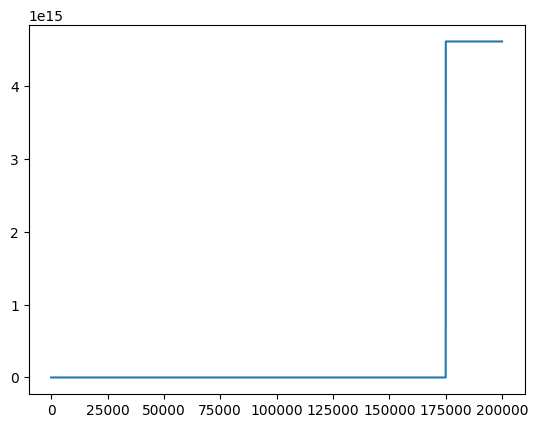

In [43]:
plt.plot(t_us)